# 00 - Exploratory Data Analysis (EDA)
## Business Entity Resolution Challenge

This notebook performs initial exploration of the training and test data:
- Load all 6 files with proper TSV parsing
- Analyze row counts, countries, null values
- Examine ground truth statistics
- Sample true positive and hard negative pairs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.append('../src')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports successful")

Imports successful


## 1. Load Data with Proper TSV Parsing

In [3]:
# Define data paths
data_root = Path('../../../student_resource/dataset')
train_dir = data_root / 'train'
test_dir = data_root / 'test'

print(f"Data root: {data_root.absolute()}")
print(f"Train dir exists: {train_dir.exists()}")
print(f"Test dir exists: {test_dir.exists()}")

Data root: c:\Users\Abhishek\Downloads\amazon_ml_student_resource\Amazon-ML-Challenge\code\business_entity_resolution\notebooks\..\..\..\student_resource\dataset
Train dir exists: True
Test dir exists: True


In [4]:
# Load training data with sep='\t'
train_s1 = pd.read_csv(train_dir / 'train_source1.tsv', sep='\t')
train_s2 = pd.read_csv(train_dir / 'train_source2.tsv', sep='\t')
train_s3 = pd.read_csv(train_dir / 'train_source3.tsv', sep='\t')
train_gt = pd.read_csv(train_dir / 'train_ground_truth.tsv', sep='\t')

print("Training data loaded:")
print(f"  Source 1: {len(train_s1):,} records")
print(f"  Source 2: {len(train_s2):,} records")
print(f"  Source 3: {len(train_s3):,} records")
print(f"  Ground truth: {len(train_gt):,} records")

Training data loaded:
  Source 1: 2,206,821 records
  Source 2: 5,034,616 records
  Source 3: 5,285,603 records
  Ground truth: 2,206,821 records


In [5]:
# Load test data
test_s1 = pd.read_csv(test_dir / 'test_source1.tsv', sep='\t')
test_s2 = pd.read_csv(test_dir / 'test_source2.tsv', sep='\t')
test_s3 = pd.read_csv(test_dir / 'test_source3.tsv', sep='\t')

print("Test data loaded:")
print(f"  Source 1: {len(test_s1):,} records")
print(f"  Source 2: {len(test_s2):,} records")
print(f"  Source 3: {len(test_s3):,} records")

Test data loaded:
  Source 1: 1,732,544 records
  Source 2: 4,887,273 records
  Source 3: 5,082,316 records


In [6]:
# Verify columns are parsed correctly (should have 4 columns, not 1)
print("\nColumn verification:")
print(f"Train S1 columns: {train_s1.columns.tolist()}")
print(f"Train S1 shape: {train_s1.shape}")
print(f"\nFirst record from Train S1:")
print(train_s1.head(1).T)


Column verification:
Train S1 columns: ['entity_id', 'business_name', 'business_address', 'country']
Train S1 shape: (2206821, 4)

First record from Train S1:
                                                       0
entity_id                                   S1-925783039
business_name                        Orelee's Barbershop
business_address  1795 Westchester Drive, High Point, NC
country                                               US


## 2. Country Distribution Analysis

In [7]:
# Country distribution in training (memory efficient - no concat)
print("Training Data - Country Distribution:")

# Get country counts per source separately
s1_countries = train_s1['country'].value_counts()
s2_countries = train_s2['country'].value_counts()
s3_countries = train_s3['country'].value_counts()

# Combine into a DataFrame
all_countries = sorted(set(s1_countries.index) | set(s2_countries.index) | set(s3_countries.index))
country_train = pd.DataFrame({
    'S1': [s1_countries.get(c, 0) for c in all_countries],
    'S2': [s2_countries.get(c, 0) for c in all_countries],
    'S3': [s3_countries.get(c, 0) for c in all_countries]
}, index=all_countries)

print(country_train)
print(f"\nUnique countries in training: {all_countries}")

Training Data - Country Distribution:
            S1       S2       S3
India   883188  2017799  2115547
US     1323633  3016817  3170056

Unique countries in training: ['India', 'US']


In [8]:
# Country distribution in test (memory efficient - no concat)
print("\nTest Data - Country Distribution:")

# Get country counts per source separately
test_s1_countries = test_s1['country'].value_counts()
test_s2_countries = test_s2['country'].value_counts()
test_s3_countries = test_s3['country'].value_counts()

# Combine into a DataFrame
all_test_countries = sorted(set(test_s1_countries.index) | set(test_s2_countries.index) | set(test_s3_countries.index))
country_test = pd.DataFrame({
    'S1': [test_s1_countries.get(c, 0) for c in all_test_countries],
    'S2': [test_s2_countries.get(c, 0) for c in all_test_countries],
    'S3': [test_s3_countries.get(c, 0) for c in all_test_countries]
}, index=all_test_countries)

print(country_test)
print(f"\nUnique countries in test: {all_test_countries}")

# Check for France in test
if 'France' in all_test_countries:
    print("\n⚠️  IMPORTANT: France appears in test data but NOT in training data!")
    print("    Must handle as open-set country problem.")


Test Data - Country Distribution:
            S1       S2       S3
France  259452   703378   731615
India   809986  2312565  2405000
US      663106  1871330  1945701

Unique countries in test: ['France', 'India', 'US']

⚠️  IMPORTANT: France appears in test data but NOT in training data!
    Must handle as open-set country problem.


## 3. Null/Empty Value Audit

In [10]:
def audit_nulls(df, name):
    """Audit null and empty values in dataframe."""
    print(f"\n{name}:")
    print("-" * 60)
    for col in df.columns:
        null_count = df[col].isnull().sum()
        empty_count = (df[col].astype(str).str.strip() == '').sum()
        total_missing = null_count + empty_count
        pct = 100 * total_missing / len(df)
        if total_missing > 0:
            print(f"  {col:20s}: {total_missing:6d} missing ({pct:5.2f}%)")
    
# Audit all datasets (no 'source' column to drop)
audit_nulls(train_s1, "Train Source 1")
audit_nulls(train_s2, "Train Source 2")
audit_nulls(train_s3, "Train Source 3")
audit_nulls(test_s1, "Test Source 1")
audit_nulls(test_s2, "Test Source 2")
audit_nulls(test_s3, "Test Source 3")


Train Source 1:
------------------------------------------------------------

Train Source 2:
------------------------------------------------------------
  business_name       :      2 missing ( 0.00%)
  business_address    : 168967 missing ( 3.36%)

Train Source 3:
------------------------------------------------------------
  business_name       :     13 missing ( 0.00%)
  business_address    : 175916 missing ( 3.33%)

Test Source 1:
------------------------------------------------------------

Test Source 2:
------------------------------------------------------------
  business_name       :     46 missing ( 0.00%)
  business_address    : 129408 missing ( 2.65%)

Test Source 3:
------------------------------------------------------------
  business_name       :     59 missing ( 0.00%)
  business_address    : 136098 missing ( 2.68%)


## 4. Ground Truth Statistics

In [11]:
# Parse matched_entity_ids
def parse_matches(match_str):
    """Parse comma-separated match IDs."""
    if pd.isna(match_str) or str(match_str).strip() == '':
        return []
    return [s.strip() for s in str(match_str).split(',') if s.strip()]

train_gt['matches'] = train_gt['matched_entity_ids'].apply(parse_matches)
train_gt['num_matches'] = train_gt['matches'].apply(len)

print("Ground Truth Statistics:")
print(f"  Total Source 1 entities: {len(train_gt):,}")
print(f"\nMatch count distribution:")
print(train_gt['num_matches'].value_counts().sort_index())

# Singleton percentage
singleton_pct = 100 * (train_gt['num_matches'] == 0).sum() / len(train_gt)
print(f"\n  Singletons (no matches): {(train_gt['num_matches'] == 0).sum():,} ({singleton_pct:.2f}%)")
print(f"  Has matches: {(train_gt['num_matches'] > 0).sum():,} ({100-singleton_pct:.2f}%)")

# Check for duplicate source1_entity_id
duplicates = train_gt['source1_entity_id'].duplicated().sum()
print(f"\n  Duplicate source1_entity_id: {duplicates}")
if duplicates > 0:
    print("  ⚠️  WARNING: Ground truth has duplicate S1 IDs!")

Ground Truth Statistics:
  Total Source 1 entities: 2,206,821

Match count distribution:
num_matches
0     123247
1     119157
2     375212
3     530841
4     484115
5     321957
6     164868
7      63968
8      18680
9       4205
10       534
11        37
Name: count, dtype: int64

  Singletons (no matches): 123,247 (5.58%)
  Has matches: 2,083,574 (94.42%)

  Duplicate source1_entity_id: 0


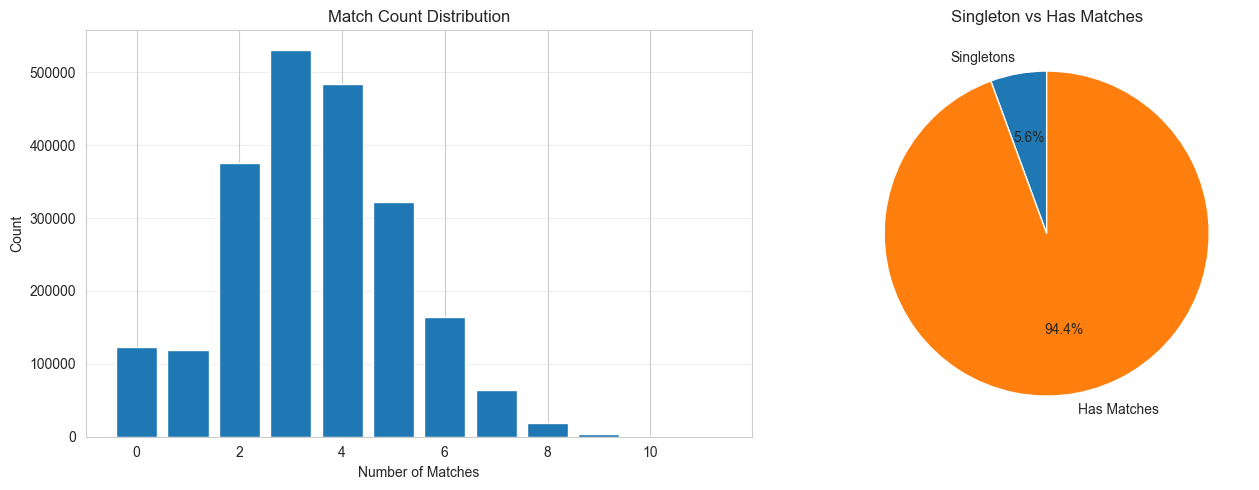

In [12]:
# Visualize match distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
match_dist = train_gt['num_matches'].value_counts().sort_index()
axes[0].bar(match_dist.index, match_dist.values)
axes[0].set_xlabel('Number of Matches')
axes[0].set_ylabel('Count')
axes[0].set_title('Match Count Distribution')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart for singleton vs non-singleton
singleton_counts = [(train_gt['num_matches'] == 0).sum(), (train_gt['num_matches'] > 0).sum()]
axes[1].pie(singleton_counts, labels=['Singletons', 'Has Matches'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Singleton vs Has Matches')

plt.tight_layout()
plt.show()

## 5. Sample True Positive Pairs

In [13]:
# Get records with matches
has_matches = train_gt[train_gt['num_matches'] > 0].sample(min(20, len(train_gt[train_gt['num_matches'] > 0])))

print("Sample True Positive Pairs (Source 1 → Matches):")
print("=" * 100)

for idx, row in has_matches.head(10).iterrows():
    s1_id = row['source1_entity_id']
    s1_rec = train_s1[train_s1['entity_id'] == s1_id].iloc[0]
    
    print(f"\n[{s1_id}] {s1_rec['business_name']}")
    print(f"  Address: {s1_rec['business_address']}")
    print(f"  Country: {s1_rec['country']}")
    print(f"  Matches ({row['num_matches']}):")
    
    for match_id in row['matches'][:3]:  # Show first 3 matches
        # Determine source
        if match_id.startswith('S2-'):
            match_rec = train_s2[train_s2['entity_id'] == match_id]
        else:
            match_rec = train_s3[train_s3['entity_id'] == match_id]
        
        if len(match_rec) > 0:
            match_rec = match_rec.iloc[0]
            print(f"    [{match_id}] {match_rec['business_name']}")
            print(f"      Address: {match_rec['business_address']}")
    print("-" * 100)

Sample True Positive Pairs (Source 1 → Matches):

[S1-868981189] Al Systems Private Limited
  Address: H. No. 466/13/6, Bhagyashree Colony Tal Hatkanangale, Ichalkranji, Kolhapur, Maharashtra
  Country: India
  Matches (2):
    [S3-206232378] अल सिस्टम्स प्राइवेट लिमिटेड
      Address: #466/13/6, Bhagyashree Colony Tal Hatkanangale, Ichalkranji, Kolhapur, MH
    [S3-227277245] अल सिस्टम्स प्राइवेट लिमिटेड
      Address: #466/13/6, Bhagyashree Colony Tal Hatkanangale, Ichalkranji, Kolhapur, MH
----------------------------------------------------------------------------------------------------

[S1-358166350] Davida's Pinnacle Publishing LLC
  Address: 37966 Neatwood Drive, San Tan Valley, AZ
  Country: US
  Matches (2):
    [S3-33110123] Davida's Pinnacle Publishing LLC
      Address: 37966 Neatwood Drive, San Tan Valley, Arizona
    [S3-123771540] Orbijax
      Address: 37966 Neatwood Dr, Queen Creek, Arizona
-----------------------------------------------------------------------------

## 6. Noise Pattern Observations

In [14]:
# Document observed noise patterns
print("\nCommon Noise Patterns to Handle:")
print("=" * 60)
print("\nBusiness Name Variations:")
print("  - Legal suffix differences (Inc/Incorporated, Pvt/Private, Ltd/Limited)")
print("  - Punctuation (& vs and, . vs no period)")
print("  - Case differences")
print("  - Abbreviations and acronyms")
print("  - Word order transpositions")
print("\nAddress Variations:")
print("  - Street type abbreviations (Rd/Road, St/Street)")
print("  - Missing/partial components (no ZIP, no state)")
print("  - Landmark-based descriptions")
print("  - Number formatting differences")
print("  - Component reordering")


Common Noise Patterns to Handle:

Business Name Variations:
  - Legal suffix differences (Inc/Incorporated, Pvt/Private, Ltd/Limited)
  - Punctuation (& vs and, . vs no period)
  - Case differences
  - Abbreviations and acronyms
  - Word order transpositions

Address Variations:
  - Street type abbreviations (Rd/Road, St/Street)
  - Missing/partial components (no ZIP, no state)
  - Landmark-based descriptions
  - Number formatting differences
  - Component reordering


## 7. Sample Singletons

In [15]:
# Sample singleton entities
singletons = train_gt[train_gt['num_matches'] == 0].sample(min(10, len(train_gt[train_gt['num_matches'] == 0])))

print("\nSample Singleton Entities (No Matches):")
print("=" * 100)

for idx, row in singletons.head(10).iterrows():
    s1_id = row['source1_entity_id']
    s1_rec = train_s1[train_s1['entity_id'] == s1_id].iloc[0]
    
    print(f"[{s1_id}] {s1_rec['business_name']}")
    print(f"  Address: {s1_rec['business_address']}")
    print(f"  Country: {s1_rec['country']}")
    print()


Sample Singleton Entities (No Matches):
[S1-675049934] Roxanna A. Patenaude, DDS, PC
  Address: 1009 Falcon Avenue, Mills, WY
  Country: US

[S1-157576137] Seven Producer Private Limited
  Address: F-1, 201 Barra -8, Kanpur Nagar, Barra, Kanpur Nagar, Uttar Pradesh
  Country: India

[S1-699059711] Sri Ganganagar Perfumes Pvt Ltd
  Address: Rajasthan, S No. 5 Stadium Ground, Sri Ganganagar, Sriganga Nagar
  Country: India

[S1-464775900] Skanda Developers
  Address: 9/51, 2Nd Floor, 80 Ft Sarakki Road, J P Nagar 1St Phase, Bangalore, Karnataka
  Country: India

[S1-903343392] Alexander Better Properties LLC
  Address: 54 Cedar Road, Mamakating, NY
  Country: US

[S1-395089949] Custom Manulife Inc
  Address: 2301 University Drive, Unit 264, Mesa, AZ
  Country: US

[S1-478593208] Gnv Trading Private Limited
  Address: Ug-39 D-211Laxman Palza Munirka, Delhi, West Delhi, New Delhi
  Country: India

[S1-879449265] Chiropractic Pioneer Medicine LLC
  Address: 1029 Cedar Creek Road, Biscoe, N

## 8. Summary Statistics

In [16]:
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

print("\nDataset Sizes:")
print(f"  Training:")
print(f"    Source 1: {len(train_s1):,} entities")
print(f"    Source 2: {len(train_s2):,} entities")
print(f"    Source 3: {len(train_s3):,} entities")
print(f"    Total: {len(train_s1) + len(train_s2) + len(train_s3):,} entities")
print(f"\n  Test:")
print(f"    Source 1: {len(test_s1):,} entities")
print(f"    Source 2: {len(test_s2):,} entities")
print(f"    Source 3: {len(test_s3):,} entities")
print(f"    Total: {len(test_s1) + len(test_s2) + len(test_s3):,} entities")

print(f"\nCountries:")
print(f"  Training: {all_countries}")
print(f"  Test: {all_test_countries}")

print(f"\nGround Truth:")
print(f"  Singletons: {(train_gt['num_matches'] == 0).sum():,} ({singleton_pct:.1f}%)")
print(f"  With matches: {(train_gt['num_matches'] > 0).sum():,} ({100-singleton_pct:.1f}%)")
print(f"  Avg matches (non-singleton): {train_gt[train_gt['num_matches'] > 0]['num_matches'].mean():.2f}")
print(f"  Max matches: {train_gt['num_matches'].max()}")

print("\n" + "=" * 80)
print("✓ EDA Complete")
print("=" * 80)


SUMMARY STATISTICS

Dataset Sizes:
  Training:
    Source 1: 2,206,821 entities
    Source 2: 5,034,616 entities
    Source 3: 5,285,603 entities
    Total: 12,527,040 entities

  Test:
    Source 1: 1,732,544 entities
    Source 2: 4,887,273 entities
    Source 3: 5,082,316 entities
    Total: 11,702,133 entities

Countries:
  Training: ['India', 'US']
  Test: ['France', 'India', 'US']

Ground Truth:
  Singletons: 123,247 (5.6%)
  With matches: 2,083,574 (94.4%)
  Avg matches (non-singleton): 3.67
  Max matches: 11

✓ EDA Complete
